# Klein et al. (2017) – Droplet Barcoding for Single-Cell Transcriptomics Applied to Embryonic Stem Cells

The original paper can be found here: https://www.sciencedirect.com/science/article/pii/S0092867415005000

__Abstract__: It has long been the dream of biologists to map gene expression at the single-cell level. With such data one might track heterogeneous cell sub-populations, and infer regulatory relationships between genes and pathways. Recently, RNA sequencing has achieved single-cell resolution. What is limiting is an effective way to routinely isolate and process large numbers of individual cells for quantitative in-depth sequencing. We have developed a high-throughput droplet-microfluidic approach for barcoding the RNA from thousands of individual cells for subsequent analysis by next-generation sequencing. The method shows a surprisingly low noise profile and is readily adaptable to other sequencing-based assays. We analyzed mouse embryonic stem cells, revealing in detail the population structure and the heterogeneous onset of differentiation after leukemia inhibitory factor (LIF) withdrawal. The reproducibility of these high-throughput single-cell data allowed us to deconstruct cell populations and infer gene expression relationships.

Klein et al. analyze 2,717 single cells. The 4 classes in which they mention are experimental conditions/timepoints:

What the 4 classes are
- 0 days (baseline mESCs, +LIF)
- 2 days after LIF withdrawal
- 4 days after LIF withdrawal
- 7 days after LIF withdrawal

Klein profiled mESCs before and after LIF withdrawal to study early differentiation dynamics; GEO lists data for baseline ES cells and LIF− at days 2, 4, 7, which are the four-condition split many benchmarks (incl. scMINER) use.

## 0. Imports & Set-Up:

In [24]:
import sys; sys.path.insert(0, "..")

import multiprocessing
import os, random

from pathlib import Path

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd

import anndata as ad

from carve import CARVE

In [38]:
SUBSAMPLE = False
subsample_size = 1000

In [39]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [40]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [41]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [42]:
from benchmarking_code.benchmarking_utils import gamma_quantile_approx
from benchmarking_code.case_study_plotting import plot_pca, calculate_baseline_aris_and_plot, baseline_metrics_over_k, alluvial_compare

---

## 1. Pre-Process the Data

In [43]:
DATA_DIR = Path("../../data/klein")
files = {
    "d0": DATA_DIR / "GSM1599494_ES_d0_main.csv.bz2",
    "d2": DATA_DIR / "GSM1599497_ES_d2_LIFminus.csv.bz2",
    "d4": DATA_DIR / "GSM1599498_ES_d4_LIFminus.csv.bz2",
    "d7": DATA_DIR / "GSM1599499_ES_d7_LIFminus.csv.bz2",
}

def read_block(path):
    df = pd.read_csv(path, header=None, index_col=0, compression="bz2")
    
    # ensure numeric (coerce odd strings to NaN and fill to 0)
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    # deduplicate any gene ids just in case
    df = df[~df.index.duplicated(keep="first")]
    
    return df  # genes × cells

read four matrices (genes × cells):

In [44]:
d0 = read_block(files["d0"])
d2 = read_block(files["d2"])
d4 = read_block(files["d4"])
d7 = read_block(files["d7"])

outer-join on genes, concat columns:

In [45]:
genes = d0.index.union(d2.index).union(d4.index).union(d7.index)
d0 = d0.reindex(genes).fillna(0.0)
d2 = d2.reindex(genes).fillna(0.0)
d4 = d4.reindex(genes).fillna(0.0)
d7 = d7.reindex(genes).fillna(0.0)

expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)  # genes × cells
print("genes × cells:", expr_gxc.shape)

genes × cells: (24175, 2717)


make unique cell ids & 4-class labels:

In [46]:
def add_prefix(df, pref):
    df.columns = [f"{pref}_{i+1:04d}" for i in range(df.shape[1])]
    return df

d0 = add_prefix(d0, "d0"); d2 = add_prefix(d2, "d2")
d4 = add_prefix(d4, "d4"); d7 = add_prefix(d7, "d7")
expr_gxc = pd.concat([d0, d2, d4, d7], axis=1)

labels = (
    ["d0"] * d0.shape[1] +
    ["d2"] * d2.shape[1] +
    ["d4"] * d4.shape[1] +
    ["d7"] * d7.shape[1]
)

cells = expr_gxc.columns
y = pd.Series(labels, index=cells, name="condition").astype("category")

build AnnData (cells × genes), keep raw counts in .layers["counts"]

In [47]:
adata = ad.AnnData(
    X=expr_gxc.T.values.astype(np.float32),  # cells × genes
    obs=pd.DataFrame(index=cells),
    var=pd.DataFrame(index=expr_gxc.index.astype(str)),
)

adata.obs["condition"] = y
adata.layers["counts"] = adata.X.copy()  # raw UMIs

print(adata)
print(adata.obs["condition"].value_counts())

AnnData object with n_obs × n_vars = 2717 × 24175
    obs: 'condition'
    layers: 'counts'
condition
d0    933
d7    798
d4    683
d2    303
Name: count, dtype: int64


---

## 2. Analyse Data

In [48]:
X = expr_gxc.T.values.astype(np.float32)

X_row_sizes = np.sum(X, axis=1)
med_lib_size = np.median(X_row_sizes)

factor = med_lib_size / X_row_sizes

X_norm = X * factor[:, None]
X = np.log1p(X_norm)

print(f"X shape (cells × genes): {X.shape[0]:,} × {X.shape[1]:,}")
print(f"y shape: {y.shape}")
print(f"Number of unique cell types in y: {y.nunique()}")

X shape (cells × genes): 2,717 × 24,175
y shape: (2717,)
Number of unique cell types in y: 4


In [49]:
# Stratified subsampling
if SUBSAMPLE:
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)

    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]

    X_sub = X[idx]
    y_sub = y.loc[selected_idx]
    
    X = X_sub
    y = y_sub

    print("X shape:", X.shape)

### 2.1 Plot PCA:

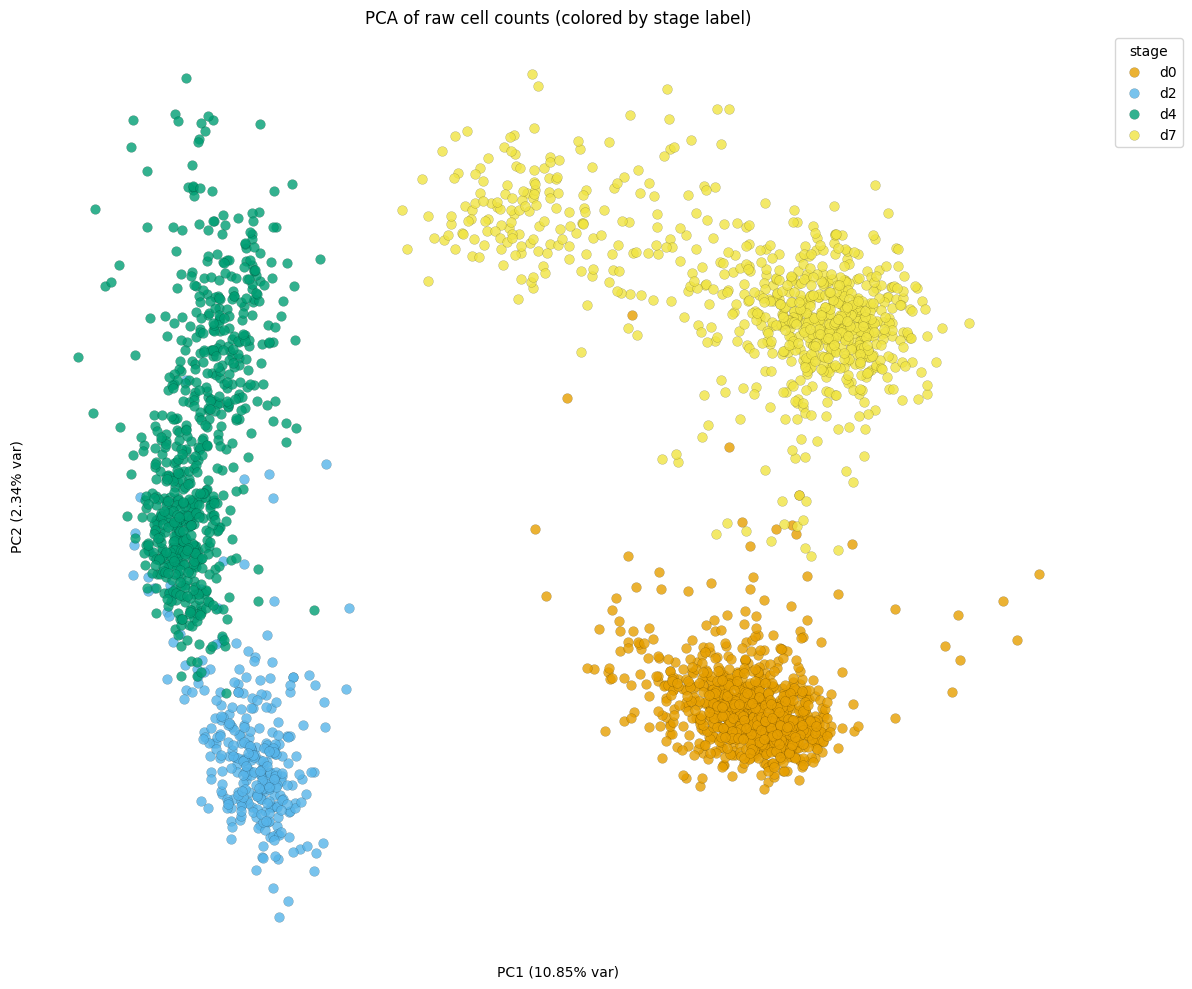

In [50]:
plot_pca(X=X, y=y)

### 2.2 Perform Clustering with "Oracle" Number of Clusters:

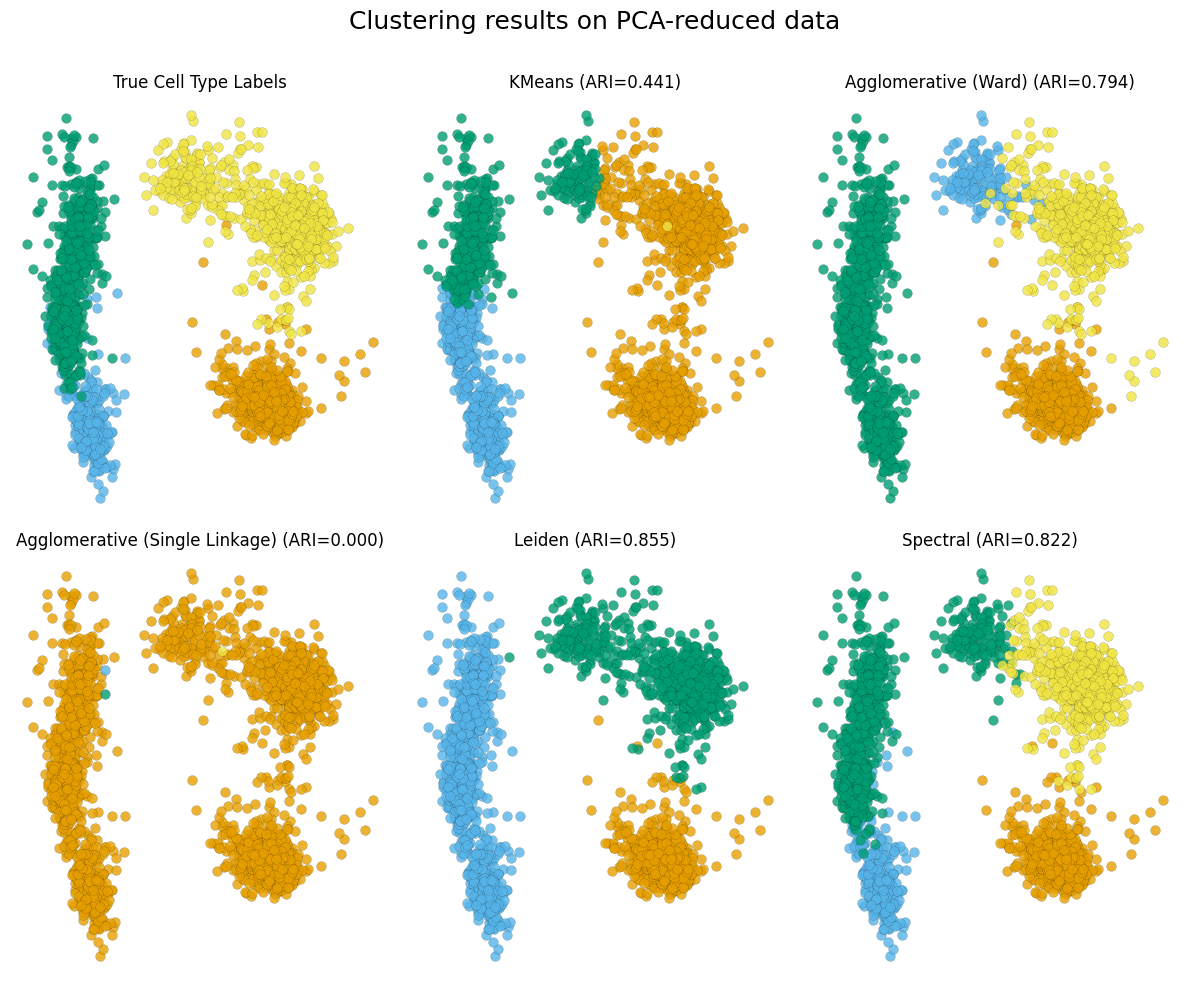

In [51]:
calculate_baseline_aris_and_plot(X=X, y=y, random_state=RANDOM_SEED)

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

In [16]:
K = 10
ks = list(range(2, K + 1))

gamma_005 = gamma_quantile_approx(X, q=0.05, random_state=RANDOM_SEED)
gamma_01  = gamma_quantile_approx(X, q=0.10, random_state=RANDOM_SEED)
gamma_05  = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)

model_grids = [
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
    (SpectralClustering, {"n_clusters": ks, "gamma": [gamma_005, gamma_01, gamma_05]})
]


baseline selections (max metric):
  - Silhouette: k=2, score=0.2673, ari=0.1612   [Spectral (gamma=0.000225)]
  - Gap Statistic: k=10, score=0.8671, ari=0.4645   [Agglomerative (linkage=ward)]
  - DB: k=2, score=0.3961, ari=0.3829   [Agglomerative (linkage=ward)]
  - CH: k=2, score=375.0775, ari=0.2859   [Spectral (gamma=4.82e-05)]


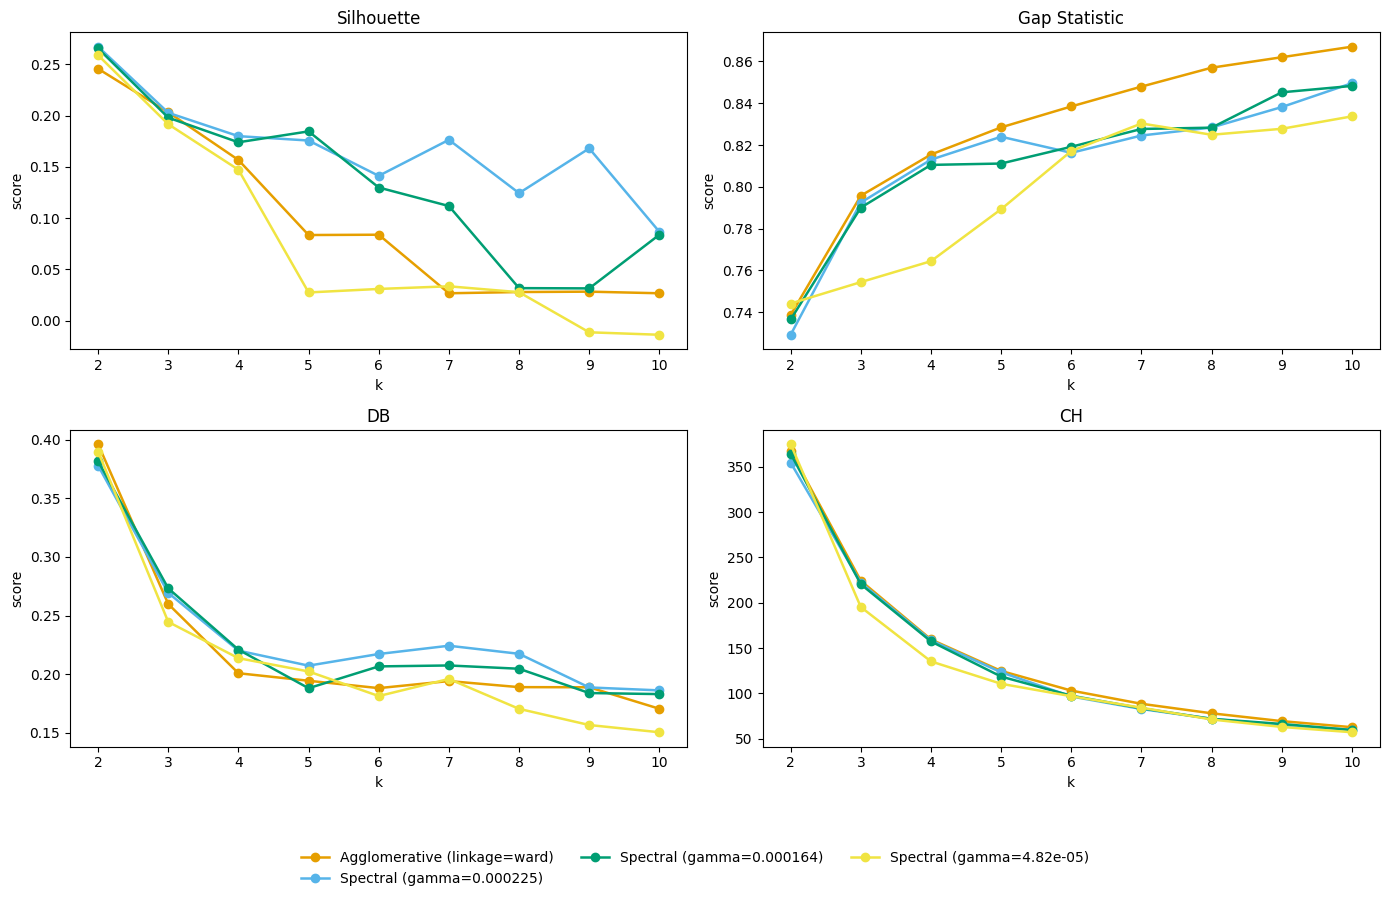

In [17]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y,                       # or None if you don't have labels
    model_grids=model_grids,   # same object you pass to CARVE
    metrics=["silhouette", "gap", "DB", "CH"],
    random_state=RANDOM_SEED,
    ncols=2,
    figsize=(14, 9),
)

---

## 4. Run CARVE:

In [18]:
carve = CARVE(
    estimator_param_grids=model_grids,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED
)

carve.fit(X, reference_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 1000
[CARVE] n_features         : 24175
[CARVE] n_clusters         : 10
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 36
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/36] est=AgglomerativeClustering n_clusters=2 | ARI_stab=0.860±0.014  ARI_gen=0.823±0.019  ARI_avg=0.842±0.014
[CARVE] [2/36] est=AgglomerativeClustering n_clusters=3 | ARI_stab=0.758±0.010  ARI_gen=0.706±0.010  ARI_avg=0.732±0.008
[CARVE] [3/36] est=AgglomerativeClustering n_clusters=4 | ARI_stab=0.750±0.011  ARI_gen=0.690±0.009  ARI_avg=0.720±0.008
[CARVE] [4/36] est=AgglomerativeClustering n_clusters=5 | ARI_stab=0.688±0.010  ARI_gen=0.664±0.009  ARI_avg=0.676±0.008
[CARVE] [5/36] es

CARVE(n_clusters=10, n_resamples=100, subsample_ratio=0.8, estimator_param_grids=[(<class 'sklearn.cluster._agglomerative.AgglomerativeClustering'>, {'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'linkage': ['ward']}), (<class 'sklearn.cluster._spectral.SpectralClustering'>, {'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'gamma': [0.00022479311037518709, 0.00016412339533389544, 4.8180466180538e-05]})], normalization_options=None, dim_reduction_options=None, reference_labels=array([0, 0, 1, 0, 0, 2, 1, 3, 1, 2, 3, 2, 0, 2, 1, 1, 0, 0, 1, 3, 1, 2,
       2, 2, 1, 2, 1, 2, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 1, 3, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 3, 1, 2, 2, 2, 2, 1, 2, 0, 0, 1, 0, 1, 2, 0, 0,
       3, 2, 0, 1, 0, 1, 2, 2, 0, 0, 1, 2, 3, 1, 1, 0, 0, 2, 2, 1, 3, 0,
       3, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 0, 0, 3, 2, 3, 2,
       0, 1, 0, 3, 0, 1, 2, 2, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 1, 1, 1, 1,
       2, 2, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 1, 2, 2, 0, 2,
       0, 0, 1, 2, 0, 2, 2, 1, 3, 0, 0, 0, 1, 0, 2, 1, 1, 0, 0, 2, 1, 0,
       1, 0, 2, 3, 1, 2, 0, 2, 1, 2, 2, 2, 0, 0, 0, 1, 2, 1, 0, 2, 0, 2,
       2, 0, 2, 1, 2, 2, 1, 2, 0, 0, 0, 3, 2, 2, 2, 2, 0, 3, 2, 1, 1, 2,
       1, 1, 0, 0, 3, 2, 2, 2, 0, 2, 0, 0, 0, 3, 0, 1, 3, 1, 2, 0, 1, 0,
       2, 3, 0, 3, 2, 2, 2, 0, 2, 3, 0, 0, 2, 2, 2, 0, 0, 0, 1, 3, 0, 2,
       1, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 1, 3, 0, 2, 1, 0, 3, 2, 1, 1, 0,
       1, 0, 2, 3, 0, 0, 0, 1, 3, 0, 0, 3, 0, 3, 3, 0, 2, 2, 2, 0, 2, 0,
       0, 0, 1, 0, 2, 2, 1, 1, 3, 2, 0, 2, 2, 2, 2, 2, 0, 1, 1, 1, 0, 1,
       3, 2, 3, 3, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1, 2, 3, 0, 2, 1, 2, 3, 1,
       2, 1, 2, 0, 2, 2, 3, 0, 2, 1, 0, 0, 1, 0, 2, 2, 0, 1, 0, 1, 2, 3,
       1, 1, 1, 2, 2, 1, 3, 0, 0, 1, 0, 1, 0, 2, 1, 1, 2, 3, 0, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 0, 1, 3, 1, 2, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 0,
       0, 1, 2, 2, 0, 1, 2, 0, 3, 0, 2, 0, 0, 1, 1, 2, 3, 0, 2, 2, 0, 2,
       1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 2, 3, 2, 1, 0,
       1, 0, 0, 2, 0, 0, 0, 0, 3, 0, 2, 1, 3, 0, 1, 1, 3, 2, 0, 3, 0, 0,
       2, 1, 1, 0, 2, 0, 0, 0, 3, 1, 0, 3, 0, 3, 2, 2, 2, 2, 1, 0, 0, 0,
       2, 3, 0, 0, 1, 0, 1, 0, 1, 3, 2, 0, 0, 1, 1, 0, 1, 2, 2, 0, 0, 2,
       3, 1, 1, 0, 0, 3, 0, 1, 1, 3, 0, 2, 0, 2, 1, 0, 1, 3, 2, 2, 0, 1,
       1, 0, 0, 0, 1, 3, 2, 1, 0, 0, 1, 0, 0, 3, 2, 0, 1, 0, 2, 1, 3, 0,
       1, 1, 2, 2, 0, 1, 1, 3, 1, 0, 0, 2, 1, 2, 1, 2, 0, 1, 2, 0, 0, 2,
       1, 2, 0, 0, 0, 1, 2, 0, 1, 2, 3, 2, 1, 0, 0, 0, 1, 1, 3, 0, 0, 0,
       0, 2, 2, 2, 2, 2, 0, 1, 0, 2, 3, 0, 1, 3, 3, 3, 2, 3, 2, 2, 0, 0,
       2, 2, 1, 2, 2, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 2,
       2, 1, 2, 2, 2, 1, 1, 0, 3, 2, 3, 2, 1, 0, 2, 2, 0, 0, 0, 1, 2, 2,
       2, 2, 3, 2, 0, 1, 3, 0, 2, 1, 0, 1, 2, 1, 0, 2, 1, 3, 2, 3, 2, 1,
       1, 2, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 3, 2, 1, 3, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 3, 0, 2, 1, 1, 3, 2, 0, 0, 2, 0, 2, 3, 2, 3,
       1, 1, 3, 0, 2, 0, 0, 0, 1, 2, 2, 2, 2, 2, 3, 2, 0, 2, 3, 3, 0, 1,
       2, 1, 2, 2, 3, 0, 2, 2, 2, 1, 3, 0, 2, 2, 1, 1, 1, 0, 0, 2, 3, 1,
       2, 1, 2, 2, 1, 1, 2, 2, 3, 3, 3, 0, 0, 0, 1, 1, 2, 0, 1, 0, 1, 3,
       2, 1, 2, 1, 2, 2, 3, 2, 0, 0, 0, 3, 0, 2, 1, 2, 1, 0, 1, 3, 1, 0,
       0, 0, 3, 0, 1, 1, 0, 2, 1, 1, 1, 2, 0, 0, 2, 2, 1, 0, 2, 0, 2, 2,
       1, 0, 1, 2, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 0, 2, 0, 2, 2, 1, 1, 1,
       2, 0, 2, 3, 3, 1, 0, 0, 1, 1, 0, 2, 3, 1, 0, 3, 2, 0, 2, 1, 3, 2,
       3, 0, 1, 1, 2, 2, 2, 1, 0, 1, 2, 0, 0, 3, 2, 3, 1, 1, 0, 3, 2, 0,
       1, 0, 1, 1, 2, 0, 2, 0, 2, 0, 0, 3, 0, 2, 0, 0, 0, 0, 0, 2, 1, 0,
       2, 0, 2, 0, 3, 1, 0, 0, 2, 0, 2, 2, 2, 0, 1, 3, 2, 2, 3, 2, 2, 0,
       0, 0, 1, 2, 0, 0, 0, 1, 3, 1, 1, 3, 3, 2, 0, 0, 0, 2, 1, 0, 1, 0,
       0, 1, 0, 2, 1, 2, 0, 1, 1, 2]), n_jobs=10, random_state=42, verbose=1, estimator_results_=                  estimator linkage  n_clusters  ari_stability  \
0   AgglomerativeClustering    ward           2       0.860382   
1   Agglome

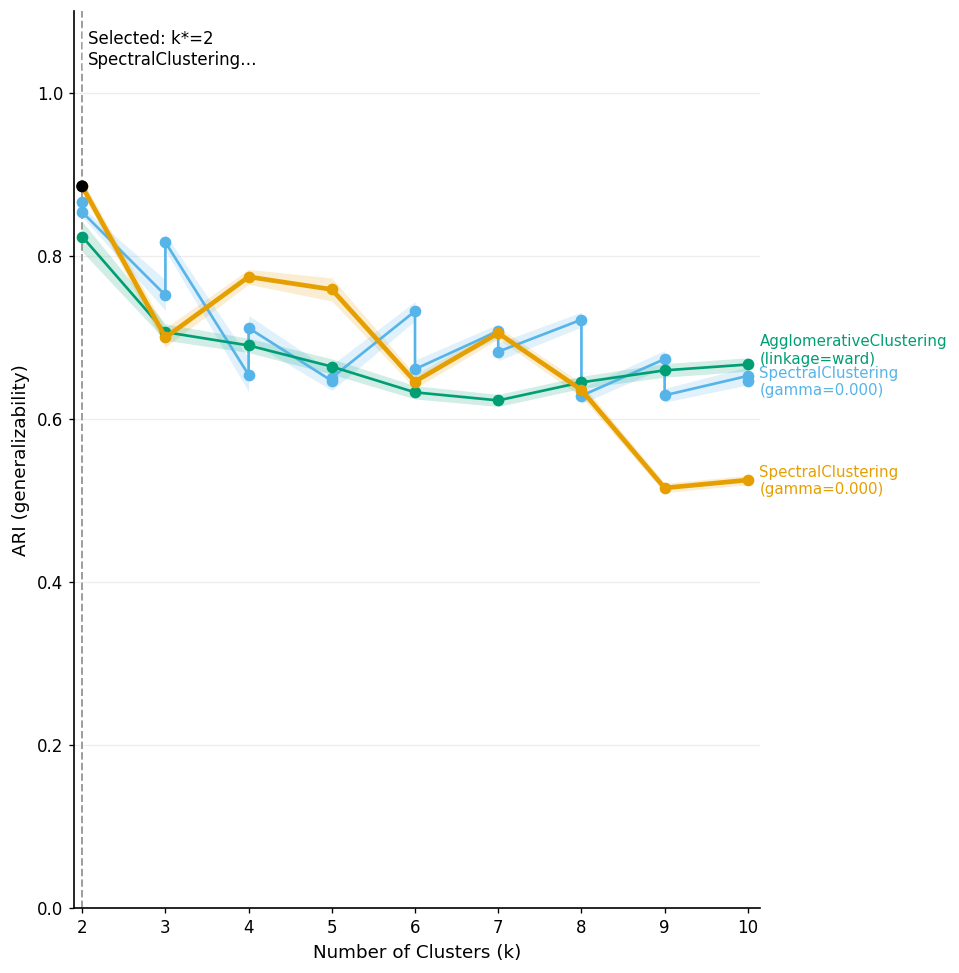

In [19]:
carve.plot_metric_over_k(measure='ari_generalizability', rule='1se', interactive=False)

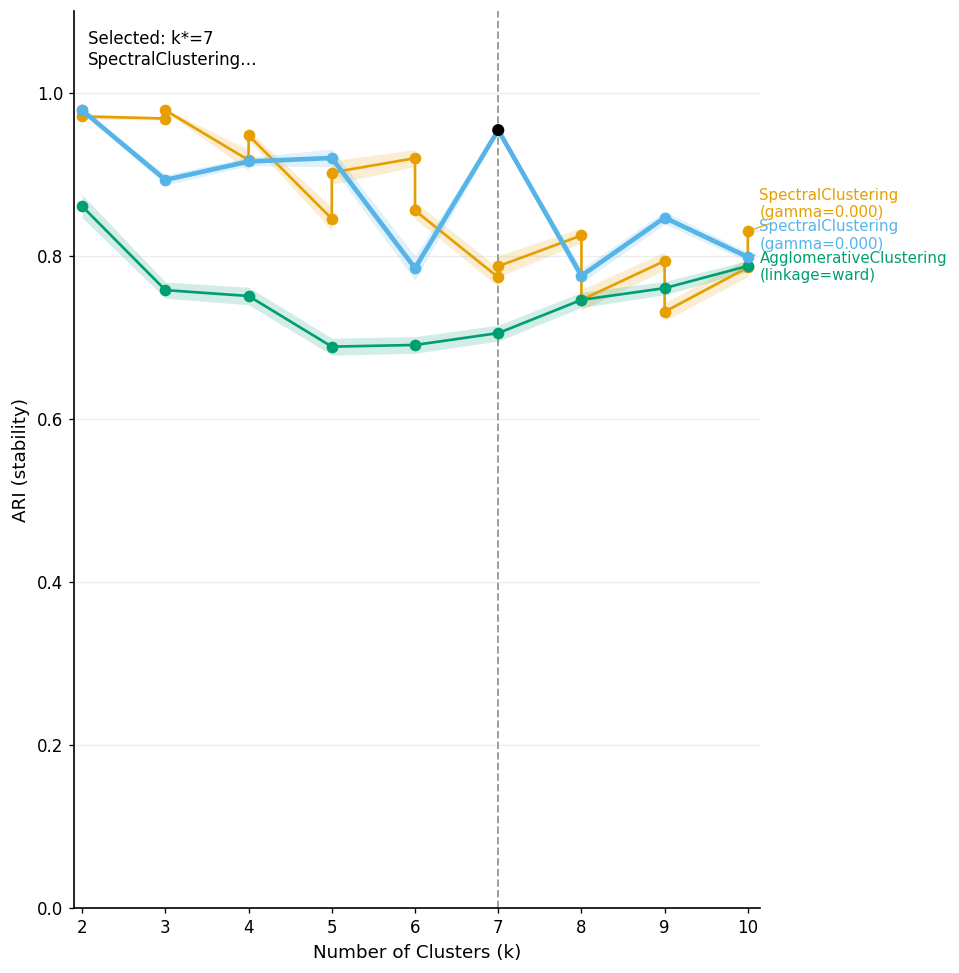

In [20]:
carve.plot_metric_over_k(measure='ari_stability', rule='quantile', interactive=False)

In [ ]:
carve.plot_cluster_summary(measure='generalizability', k=4, rule='1se')

In [ ]:
carve.plot_cluster_summary(k=4, measure='stability', rule='quantile', interactive=False)

In [22]:
# Agglomerative k=4 (Ward) –– as suggested by silhouette 
silhouette_labels = SpectralClustering(n_clusters=2, gamma=gamma_005, random_state=RANDOM_SEED).fit_predict(X)

# Spectral, k=7 –– as suggested by CARVE generalizability 
carve_labels = carve.get_labels(k=4, measure="generalizability", rule="1se")

fig = alluvial_compare(
    y_true=y,
    left_labels=carve_labels,
    right_labels=silhouette_labels,
    left_title="CARVE",
    right_title="silhouette",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()


---